<a href="https://colab.research.google.com/github/202204417/25-2-DIP-202204417/blob/main/HW_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os
import cv2
from scipy import ndimage
from skimage.measure import label, regionprops

In [11]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/DIP_Brain_Data'
FILE_S01 = os.path.join(DATA_PATH, 's01.nii.gz')
FILE_S02 = os.path.join(DATA_PATH, 's02.nii.gz')
K_VENTRICLE = 3
MIN_PIXEL_VALUE = 10

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
def load_nifti_data(filepath):
    """NIfTI 파일을 로드하고 3D NumPy 데이터를 반환합니다."""
    try:
        img = nib.load(filepath)
        data = img.get_fdata().astype(np.float64)
        print(f"Loaded: {os.path.basename(filepath)}, Shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def remove_small_objects(mask, min_size):
    """
    Gland Segmentation에서 활용한 Area Filtering 기법.
    여기서는 가장 큰 연결 성분(Ventricle)만 남깁니다.
    """
    labeled_mask = label(mask)
    props = regionprops(labeled_mask)
    clean_mask = np.zeros_like(mask, dtype=np.uint8)

    # 픽셀 면적이 가장 큰 영역 (Ventricle)만 선택
    if props:
        # 면적이 가장 큰 영역의 속성을 찾습니다.
        max_area_prop = max(props, key=lambda prop: prop.area)
        if max_area_prop.area >= min_size:
            clean_mask[labeled_mask == max_area_prop.label] = 255
            return clean_mask, max_area_prop.area

    return clean_mask, 0

In [13]:
def find_largest_ventricle_slice(data, k_clusters=K_VENTRICLE):
    """3D NIfTI 데이터에서 Ventricle 면적이 가장 큰 2D slice를 찾습니다."""
    max_area = -1
    best_slice_index = -1

    # MRI에서 Ventricle(CSF)은 가장 어두운 픽셀 값을 가집니다.
    print("\n--- [1. 가장 큰 Lateral Ventricle Slice 찾기] ---")

    for i in range(data.shape[2]): # Z축(slice) 순회
        slice_2d = data[:, :, i].copy()
        if np.max(slice_2d) < MIN_PIXEL_VALUE: continue

        # K-Means Clustering 준비 및 실행 (Lab07 기법 활용)
        pixel_values = slice_2d.flatten()
        pixel_values = pixel_values[pixel_values >= MIN_PIXEL_VALUE]

        if len(pixel_values) < k_clusters * 10: continue

        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        _, labels, centers = cv2.kmeans(pixel_values.reshape(-1, 1).astype(np.float32), k_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

        # CSF/Ventricle 식별: 가장 낮은 픽셀 값(어두움)을 가진 클러스터
        centers = centers.flatten()
        csf_idx = np.argmin(centers)

        # 마스크 생성
        labels_full = np.zeros_like(slice_2d.flatten())
        labels_full[slice_2d.flatten() >= MIN_PIXEL_VALUE] = labels.flatten()
        labels_full = labels_full.reshape(slice_2d.shape)

        csf_mask_raw = (labels_full == csf_idx).astype(np.uint8) * 255

        # 면적 필터링: CSF 중 가장 큰 영역(Ventricle)의 면적 계산
        _, current_area = remove_small_objects(csf_mask_raw, min_size=100)

        if current_area > max_area:
            max_area = current_area
            best_slice_index = i

    return best_slice_index, max_area

In [14]:
def process_and_compare_slices(data_s01, data_s02, best_slice_index):
    """최적의 slice에 대해 뇌와 측뇌실 분할을 수행하고 면적을 비교합니다."""

    results = {}
    slice_s01 = data_s01[:, :, best_slice_index]
    slice_s02 = data_s02[:, :, best_slice_index]

    # --- [Session 2 실행] Brain Segmentation (Global Thresholding) ---
    print("\n--- [2. Brain Segmentation 실행] Global Thresholding ---")

    # Otsu Thresholding을 위해 0-255 범위로 정규화
    slice_s01_uint = cv2.normalize(slice_s01, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    slice_s02_uint = cv2.normalize(slice_s02, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Otsu 방법을 통해 뇌 영역 분리 (Lab03/05 임계값 기법 활용)
    _, brain_mask_s01 = cv2.threshold(slice_s01_uint, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    _, brain_mask_s02 = cv2.threshold(slice_s02_uint, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    area_s01_brain = np.sum(brain_mask_s01 > 0)
    area_s02_brain = np.sum(brain_mask_s02 > 0)

    print(f"   S01 Brain 면적: {area_s01_brain} 픽셀")
    print(f"   S02 Brain 면적: {area_s02_brain} 픽셀")
    results['brain'] = (brain_mask_s01, brain_mask_s02, area_s01_brain, area_s02_brain)

    # --- [Session 3 실행] Lateral Ventricle Segmentation (K-Means Clustering) ---
    print("\n--- [3. Ventricle Segmentation 실행] K-Means Clustering ---")

    def segment_ventricle_kmeans(slice_data):
        slice_norm = slice_data.copy()
        slice_norm[np.isnan(slice_norm)] = 0

        pixel_values = slice_norm.flatten()
        pixel_values = pixel_values[pixel_values >= MIN_PIXEL_VALUE]

        if len(pixel_values) < K_VENTRICLE * 10:
            return np.zeros_like(slice_data, dtype=np.uint8), 0

        # K-Means 실행 (Lab07 클러스터링 기법 활용)
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        _, labels, centers = cv2.kmeans(pixel_values.reshape(-1, 1).astype(np.float32), K_VENTRICLE, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

        # CSF/Ventricle은 가장 어두운 클러스터
        csf_idx = np.argmin(centers.flatten())

        # 라벨 재매핑
        labels_full = np.zeros_like(slice_data.flatten())
        labels_full[slice_norm.flatten() >= MIN_PIXEL_VALUE] = labels.flatten()
        labels_full = labels_full.reshape(slice_data.shape)

        ventricle_mask_raw = (labels_full == csf_idx).astype(np.uint8) * 255

        # 면적 필터링: 가장 큰 영역(측뇌실)만 남기기 (Gland Area Filtering과 동일)
        ventricle_mask, area = remove_small_objects(ventricle_mask_raw, min_size=100)

        return ventricle_mask, area

    ventricle_mask_s01, area_s01_ventricle = segment_ventricle_kmeans(slice_s01)
    ventricle_mask_s02, area_s02_ventricle = segment_ventricle_kmeans(slice_s02)

    print(f"   S01 Lateral Ventricle 면적: {area_s01_ventricle} 픽셀")
    print(f"   S02 Lateral Ventricle 면적: {area_s02_ventricle} 픽셀")
    results['ventricle'] = (ventricle_mask_s01, ventricle_mask_s02, area_s01_ventricle, area_s02_ventricle)

    return results

Loaded: s01.nii.gz, Shape: (256, 256, 32)
Loaded: s02.nii.gz, Shape: (256, 256, 32)

--- [1. 가장 큰 Lateral Ventricle Slice 찾기] ---

[Session 1 결과] S01에서 Lateral Ventricle이 가장 큰 Slice Index: 29 (면적: 40932.0)


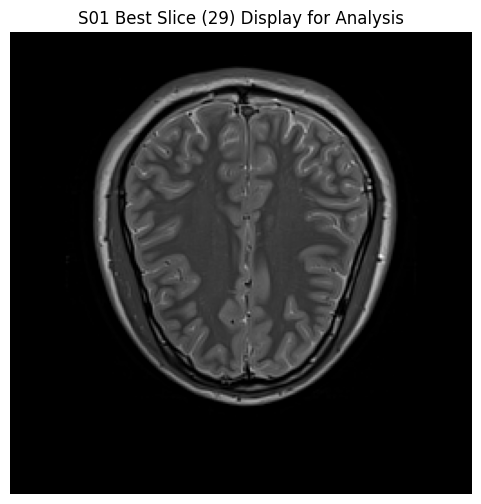


--- [2. Brain Segmentation 실행] Global Thresholding ---
   S01 Brain 면적: 22113 픽셀
   S02 Brain 면적: 16817 픽셀

--- [3. Ventricle Segmentation 실행] K-Means Clustering ---
   S01 Lateral Ventricle 면적: 40932.0 픽셀
   S02 Lateral Ventricle 면적: 46441.0 픽셀


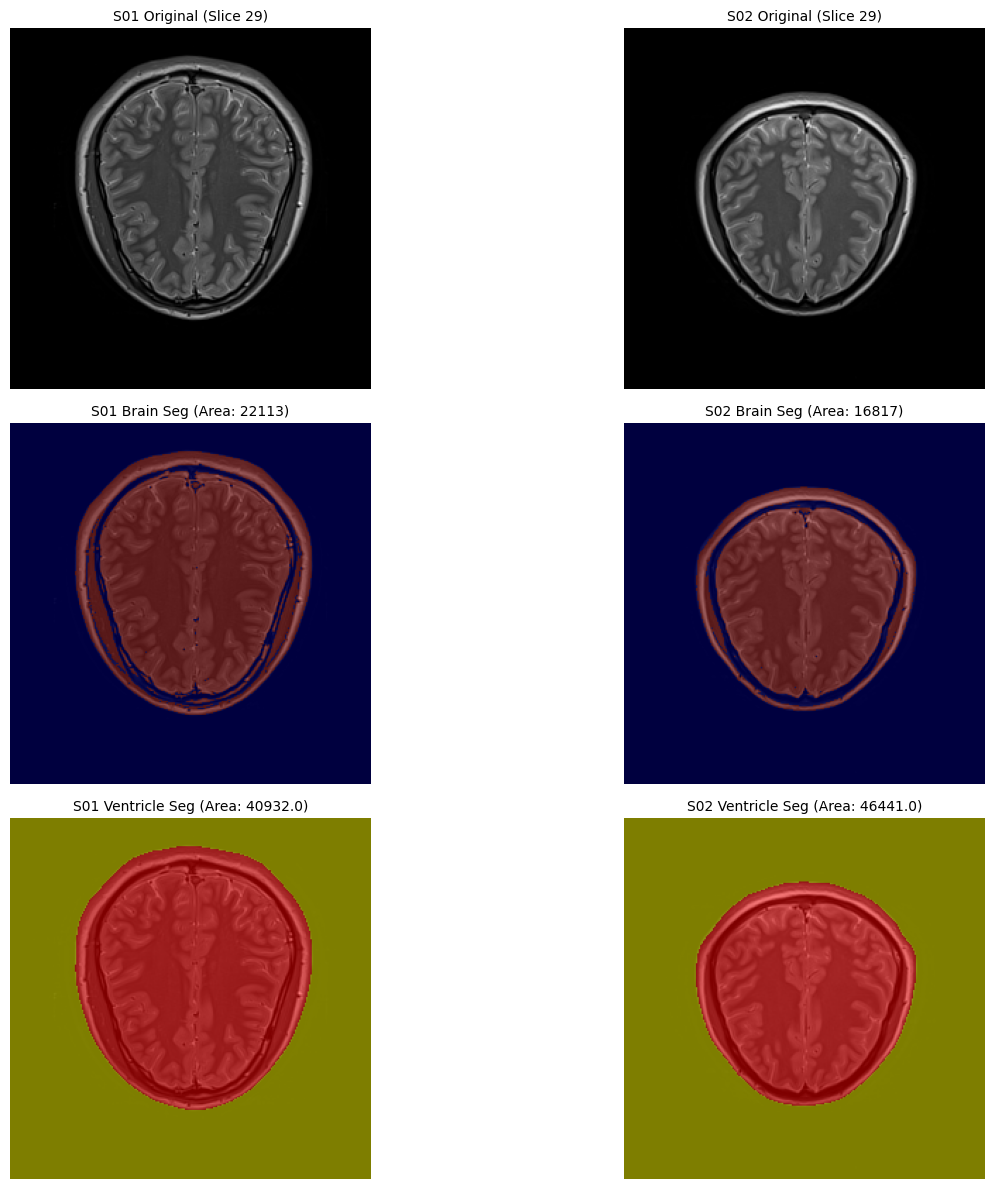

In [15]:
def display_results(slice_s01, slice_s02, results, slice_idx):
    """분할 결과를 시각화합니다."""

    brain_mask_s01, brain_mask_s02, area_s01_brain, area_s02_brain = results['brain']
    ventricle_mask_s01, ventricle_mask_s02, area_s01_ventricle, area_s02_ventricle = results['ventricle']

    plt.figure(figsize=(15, 12))

    # 1행: S01 & S02 Original Images
    plt.subplot(3, 2, 1)
    plt.imshow(slice_s01.T, cmap='gray')
    plt.title(f"S01 Original (Slice {slice_idx})", fontsize=10)
    plt.axis('off')

    plt.subplot(3, 2, 2)
    plt.imshow(slice_s02.T, cmap='gray')
    plt.title(f"S02 Original (Slice {slice_idx})", fontsize=10)
    plt.axis('off')

    # 2행: Brain Segmentation Comparison
    plt.subplot(3, 2, 3)
    plt.imshow(slice_s01.T, cmap='gray')
    plt.imshow(brain_mask_s01.T, alpha=0.5, cmap='jet')
    plt.title(f"S01 Brain Seg (Area: {area_s01_brain})", fontsize=10)
    plt.axis('off')

    plt.subplot(3, 2, 4)
    plt.imshow(slice_s02.T, cmap='gray')
    plt.imshow(brain_mask_s02.T, alpha=0.5, cmap='jet')
    plt.title(f"S02 Brain Seg (Area: {area_s02_brain})", fontsize=10)
    plt.axis('off')

    # 3행: Lateral Ventricle Segmentation Comparison
    plt.subplot(3, 2, 5)
    plt.imshow(slice_s01.T, cmap='gray')
    plt.imshow(ventricle_mask_s01.T, alpha=0.5, cmap='autumn')
    plt.title(f"S01 Ventricle Seg (Area: {area_s01_ventricle})", fontsize=10)
    plt.axis('off')

    plt.subplot(3, 2, 6)
    plt.imshow(slice_s02.T, cmap='gray')
    plt.imshow(ventricle_mask_s02.T, alpha=0.5, cmap='autumn')
    plt.title(f"S02 Ventricle Seg (Area: {area_s02_ventricle})", fontsize=10)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# =================================================================
# [Main Execution] - 전체 실행 흐름
# =================================================================
def main():
    # NIfTI 파일 로드
    data_s01 = load_nifti_data(FILE_S01)
    data_s02 = load_nifti_data(FILE_S02)

    if data_s01 is None or data_s02 is None:
        print("파일 로드 실패. 경로를 확인하세요.")
        return

    # [1. Lateral Ventricle 면적이 가장 큰 Slice 찾기 및 Display]
    # -------------------------------------------------------------
    best_slice_s01, max_area_s01 = find_largest_ventricle_slice(data_s01)

    if best_slice_s01 != -1:
        print(f"\n[Session 1 결과] S01에서 Lateral Ventricle이 가장 큰 Slice Index: {best_slice_s01} (면적: {max_area_s01})")

        # 찾은 슬라이스 디스플레이 (요청 사항 1번의 Display)
        plt.figure(figsize=(6, 6))
        plt.imshow(data_s01[:, :, best_slice_s01].T, cmap='gray')
        plt.title(f"S01 Best Slice ({best_slice_s01}) Display for Analysis")
        plt.axis('off')
        plt.show()

        # ---------------------------------------------------------
        # [2. Brain Segmentation] & [3. Ventricle Segmentation] 실행
        # ---------------------------------------------------------
        results = process_and_compare_slices(data_s01, data_s02, best_slice_s01)

        # 최종 결과 시각화
        display_results(data_s01[:, :, best_slice_s01], data_s02[:, :, best_slice_s01], results, best_slice_s01)
    else:
        print("\n[오류] Lateral Ventricle 영역을 찾을 수 없습니다. 데이터 범위 또는 K-Means 클러스터 수를 점검하세요.")

if __name__ == '__main__':
    main()